# Day 32: Polynomial Regression

---

## 📌 Objectives:
- Understand **Polynomial Regression** and its applications.
- Learn how Polynomial Regression models **non-linear relationships**.
- Implement Polynomial Regression **from scratch** using a dataset.
- Apply the model to predict outcomes on a real-world dataset.
- Visualize results to compare Polynomial Regression with Linear Regression.

---

## 🤔 What is Polynomial Regression?

### 🔹 Definition:
Polynomial Regression is an extension of **Linear Regression**, where instead of fitting a straight line, we fit a polynomial curve to capture **non-linear** relationships in data.

### 🔹 Mathematical Representation:
A Polynomial Regression model is represented as:

$$ (y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + ... + \beta_n x^n + \epsilon ) $$

Where:
- \( y \) is the target variable.
- \( x \) is the predictor variable.
- \( \beta_0, \beta_1, ..., \beta_n \) are the model coefficients.
- \( n \) is the polynomial degree.
- \( \epsilon \) is the error term.

### 🔹 When to Use Polynomial Regression?
- When the data shows **non-linear trends**.
- When a **higher-degree curve** fits the data better than a straight line.
- When **Linear Regression fails** to capture the pattern in data.

---

## 📊 Dataset: **Synthetic Dataset for Polynomial Regression**
For hands-on practice, we will generate a **synthetic dataset** that exhibits a non-linear relationship.

---

## 🛠️ Implementing Polynomial Regression

---


In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
#Generate a dataset
np.random.seed(42)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 2 * X**3 -3 * X**2 + X + np.random.randn(100,1) * 3

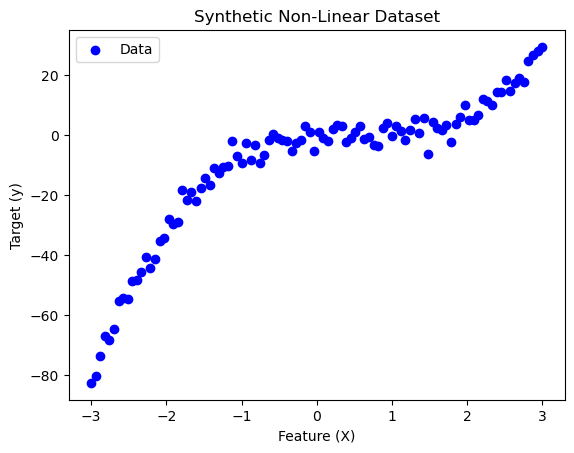

In [4]:
#Visualize the dataset
plt.scatter(X, y, color='blue', label='Data')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('Synthetic Non-Linear Dataset')
plt.legend()
plt.show()

## 3. Train-Test Split

---

In [5]:
#Split the data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

## 4. Implement Linear Regression

---

In [6]:
# Fit a simple Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [7]:
#Predictions
y_pred_linear = linear_model.predict(X_test)

In [8]:
#Evaluate Linear Model
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

In [9]:
print(f'Linear Regression MSE: {mse_linear:.4f}')
print(f'Linear Regression R2: {r2_linear:.4f}')

Linear Regression MSE: 194.5731
Linear Regression R2: 0.7048


---

## 5. Implement Polynomial Regression

---


In [10]:
# Transform features to polynomial degree 3
poly_features = PolynomialFeatures(degree=3)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [11]:
# Train Polynomial Regression Model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [12]:
#Predictions
y_pred_poly = poly_model.predict(X_test_poly)

In [13]:
#Evaluate Polynomial Model
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

In [14]:
print(f'Polynomial Regression MSE: {mse_poly:.4f}')
print(f'Polynomial Regression R2: {r2_poly:.4f}')

Polynomial Regression MSE: 5.4202
Polynomial Regression R2: 0.9918


---

## 6. Visualizing the Models

---

In [15]:
#Sort X values for smooth curve
X_curve = np.linspace(-3, 3, 100).reshape(-1,1)
X_curve_poly = poly_features.transform(X_curve)

y_curve_linear = linear_model.predict(X_curve)
y_curve_poly = poly_model.predict(X_curve_poly)

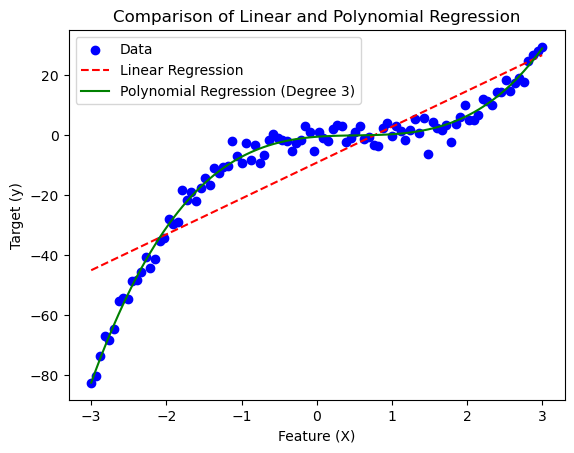

In [17]:
#plot results
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X_curve, y_curve_linear, color='red', linestyle='--', label='Linear Regression')
plt.plot(X_curve, y_curve_poly, color='green', linestyle='-', label='Polynomial Regression (Degree 3)')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('Comparison of Linear and Polynomial Regression')
plt.legend()
plt.show()

## 📈 Interpretation of Results

### 🔹 Key Observations:
- The **Linear Regression model** fails to capture the non-linear trend.
- The **Polynomial Regression model** provides a much better fit with **higher R² and lower MSE**.
- The visualization clearly shows how Polynomial Regression **curves with the data** instead of fitting a straight line.

---

## ✅ Conclusion

- **Polynomial Regression** helps capture **non-linear relationships** that Linear Regression cannot.
- Choosing the **right polynomial degree** is crucial to avoid **underfitting (low-degree) or overfitting (high-degree)**.
- Proper visualization aids in understanding model performance.
- This technique is valuable in fields like **economics, finance, physics, and biology**, where real-world relationships are often **non-linear**.

---